In [24]:
import os
from os import path
from packaging import version
from decimal import Decimal

from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import numpy as np
from scipy.ndimage import binary_dilation

# from hciplot import plot_frames, plot_cubes

from astropy.io import fits
from astropy.modeling import fitting, models
from astropy.nddata import Cutout2D
from astropy.wcs import WCS

from astropy.convolution import Gaussian2DKernel, convolve, interpolate_replace_nans
from astropy.stats import sigma_clip, mad_std, sigma_clipped_stats

from astropy.units.quantity import Quantity
from astropy import units as u
from astropy import constants as const
from astropy.nddata import Cutout2D

from photutils.aperture import aperture_photometry, CircularAperture, EllipticalAperture, EllipticalAnnulus

from jwst import datamodels
from gwcs.wcstools import grid_from_bounding_box
# from reproject import reproject_interp
# import photutils

from scipy.ndimage import rotate, shift
from scipy.stats import scoreatpercentile

# from skimage import color, data, restoration

import pandas as pd
import seaborn as sns

from vip_hci.preproc import cube_recenter_dft_upsampling

#%matplotlib inline
%matplotlib inline

In [25]:
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:95% !important; }</style>"))

In [26]:
import vip_hci as vip
import matplotlib.pyplot as plt
vvip = vip.__version__
print("VIP version: ", vvip)
if version.parse(vvip) < version.parse("1.0.0"):
    msg = "Please upgrade your version of VIP"
    msg+= "It should be 1.0.0 or above to run this notebook."
    raise ValueError(msg)
elif version.parse(vvip) <= version.parse("1.0.3"):
    from vip_hci.conf import time_ini, timing
else:
    from vip_hci.config import time_ini, timing
# common to all versions:
from vip_hci.fits import open_fits, write_fits, info_fits
from vip_hci.preproc import (frame_crop, frame_px_resampling,
                             frame_rotate, frame_shift, cube_crop_frames,
                             cube_derotate, cube_shift,
                             approx_stellar_position, cube_recenter_2dfit)
                             
from vip_hci.var import mask_circle

# from utils_bkg_MS import approx_stellar_position, mask_circle, fit_2dgaussian
from scipy.interpolate import UnivariateSpline

# from vip_hci.preproc import frame_center
pd.set_option('display.max_rows', 200)

VIP version:  2.0.1


In [27]:
def absolute_yx_to_relative_yx(absolute_yx, image_center_yx):
    """Convert absolute cartesian position to relative position.
    """

    absolute_yx = np.array(absolute_yx, dtype='float64')
    image_center_yx = np.array(image_center_yx)
    relative_yx = absolute_yx - image_center_yx
    return relative_yx

def relative_yx_to_rhophi(relative_yx):
    """Convert relative cartesian to polar coordinates.
    """

    relative_yx = np.array(relative_yx, dtype='float64')
    if len(relative_yx.shape) == 1:
        relative_yx = np.expand_dims(relative_yx, axis=0)
    if len(relative_yx.shape) == 2:
        rho = np.linalg.norm(relative_yx, axis=1)
        phi = np.arctan2(relative_yx[:, 1], relative_yx[:, 0])
    else:
        raise ValueError("Coordinates to a single tuple or list of tuples.")

    phi *= -1.
    mask = phi < 0
    # Add 2pi to negative value to change range from [-pi, pi] to [0, 2pi]
    phi[mask] += 2 * np.pi
    phi = phi * 360. / (2. * np.pi) % 360.
    rhophi = np.vstack([rho, phi]).T.squeeze()
    return rhophi

def fit_2d_gaussian(
        image, yx_position=None, yx_center=None, x_stddev=1.43, y_stddev=2.63,
        box_size=7, mask_deviating=False, deviation_threshold=0.1,
        fix_width=True, fix_orientation=True, plot=False):

    if yx_center is None:
        yx_center = (image.shape[0] // 2., image.shape[1] // 2)
    # spot fitting
    if yx_position is None:
        cy, cx = np.unravel_index(np.nanargmax(image), image.shape)
    else:
        cy, cx = yx_position
    cutout = Cutout2D(image, (cx, cy), box_size)
    # stamp = image[cy - box_size:cy + box_size, cx - box_size:cx + box_size].copy()
    xx, yy = np.meshgrid(np.arange(box_size), np.arange(box_size))
    yx_position_cutout = np.unravel_index(np.nanargmax(cutout.data), cutout.shape)
    gbounds = {
        'amplitude': (1e-9, None),
        'x_mean': (-2.0, box_size+2),
        'y_mean': (-2.0, box_size+2),
        'x_stddev': (0.5, box_size),
        'y_stddev': (0.5, box_size)
    }
    relative_yx = absolute_yx_to_relative_yx(yx_position, yx_center)
    rhophi = relative_yx_to_rhophi(relative_yx)
    phi = rhophi[1] * np.pi / 180.

    g_init = models.Gaussian2D(
        amplitude=np.nanmax(cutout.data),
        x_mean=yx_position_cutout[1],
        y_mean=yx_position_cutout[0],
        x_stddev=x_stddev,
        y_stddev=y_stddev,
        theta=phi,
        bounds=gbounds)  # + models.Const2D(amplitude=stamp.min())

    if fix_width:
        g_init.x_stddev.fixed = True
        g_init.y_stddev.fixed = True
    if fix_orientation:
        g_init.theta.fixed = True

    finite_mask = np.logical_and(np.isfinite(cutout.data), cutout.data != 0.)
    fitter = fitting.LevMarLSQFitter()
    par = fitter(g_init, xx[finite_mask], yy[finite_mask], cutout.data[finite_mask])
    model = par(xx, yy)
    if plot:
        plt.imshow(cutout.data, origin='lower')
        plt.show()
        plt.imshow(model, origin='lower')
        plt.show()

    # Check if model fit is close to data (this is not perfect in case the detection is on the edge)
    # May require special treatment or warning
    mask = abs(cutout.data - model) / np.nanmean(
        np.vstack([cutout.data[None, :], model[None, :]]), axis=0) < deviation_threshold  # Filter out
    if mask_deviating:
        g_init = models.Gaussian2D(
            amplitude=par.amplitude.value,
            x_mean=par.x_mean.value,
            y_mean=par.y_mean.value,
            x_stddev=par.x_stddev.value,
            y_stddev=par.y_stddev.value,
            theta=par.theta.value)
        par = fitter(g_init, xx[mask], yy[mask], cutout.data[mask])
        model = par(xx, yy)

    # Cutout works with x first and y second
    xy_fit_position_orig = cutout.to_original_position((par.x_mean.value, par.y_mean.value))
    yx_fit_position_orig = xy_fit_position_orig[::-1]
    yx_fit_relative = (xy_fit_position_orig[1] - yx_center[0],
                       xy_fit_position_orig[0] - yx_center[1])

    fwhm_area = par.x_stddev.value * par.y_stddev.value * 2.355**2 * np.pi

    parameters = {
        'parameters': par, 'model': model, 'cutout': cutout.data,
        'yx_fit_position_orig': yx_fit_position_orig,
        'yx_fit_relative': yx_fit_relative,
        'mask': mask,
        'fwhm_area': fwhm_area
    }

    return parameters

In [28]:
from astropy.stats import sigma_clip

def weighted_average(y, variance, mask_outliers=True, sigma=3.5):
    mask = np.logical_and(np.isfinite(y), y != 0.)
    if mask_outliers:
#      mask = mask = np.ones_like(values, dtype='bool')
        y_clipped = sigma_clip(y, sigma=3.5, cenfunc=np.nanmedian, stdfunc=np.nanstd, axis=0, masked=True)
        mask = np.logical_and(~y_clipped.mask, mask)
    if not np.all(~mask):
        weighted_average = np.average(
            y[mask],
            weights=np.ones_like(y[mask]) / variance[mask])

        weight_for_variance = np.ones_like(y[mask]) / variance[mask]
        uncertainty = np.sqrt(1 / np.sum(weight_for_variance))
    else:
        weighted_average = np.nan
        uncertainty = np.nan
        
    return weighted_average, uncertainty

In [29]:
flux_column = "RF_FLUX"
# flux_column = "FLUX"

def read_wavelength(fname_x1d):
#         try:
        dm = datamodels.open(fname_x1d)
        wl = np.array(dm.spec[0].spec_table['WAVELENGTH'])
        flux = np.array(dm.spec[0].spec_table[flux_column])
        channel = dm.meta.instrument.channel
        dm.close()
#         except:
#             hdu = fits.open(fname_x1d)
#             wl = hdu[1].data['WAVELENGTH']
        
        basename, _ = os.path.splitext(os.path.basename(fname_x1d))
        print(basename)
        if 'long' in basename:
            band = 'long'
            band_num = 'C'
        elif 'medium' in basename:
            band = 'medium'
            band_num = 'B'
        elif 'short' in basename:
            band ='short'
            band_num = 'A'

        band_id = f'{channel}'+f'{band_num}'
         
        wl2 = np.empty(len(wl))
        wl2[:] = wl

        hdul = fits.open(fname_x1d)
        hdul.verify('ignore')
        table = hdul[1].data
        cols = hdul[1].columns
        ncols = cols.names
        flux = table[flux_column]
        flux_error = table['FLUX_ERROR']
        
        flux2 = np.empty(len(flux))
        flux2[:] = flux
        
        flux_error2 = np.empty(len(flux_error))
        flux_error2[:] = flux_error
        hdul.close()

        return wl2, band_id, flux2
    
def bin_data(cube, wavelength=None, binning=20, slice_indices=[0, 880], weigthed_average=False, sigma_clip=True, sigma=3., cenfunc=np.nanmedian,
            stdfunc=np.nanstd, flux=None):

    cube_size = cube.shape
    cube_bin = cube[slice_indices[0]:slice_indices[1]].copy()
#     print(f"Cube size: {cube_bin.shapecenfunc='median', stdfunc='std', axis=None, masked=True}")
    cube_bin = cube_bin.reshape(-1, binning, cube_size[-2], cube_size[-1])
#     print(f"Cube size after reshaping: {cube_bin.shape}")
    wave_bin = wavelength[slice_indices[0]:slice_indices[1]].copy()
#     print(f"Wave array size: {wave_bin.shape}")
    wave_bin = wave_bin.reshape(-1, binning)
#     print(f"Wave array size after reshape: {wave_bin.shape}")

    if flux is not None:
        flux_bin = flux[slice_indices[0]:slice_indices[1]].copy()
#     print(f"Wave array size: {wave_bin.shape}")
        flux_bin = flux_bin.reshape(-1, binning)
    else:
        flux_bin = None
    
   
    if sigma_clip:    
        _, cube_bin, _ = sigma_clipped_stats(
            cube_bin, sigma=3.0, 
            maxiters=5, cenfunc=cenfunc, stdfunc=stdfunc, axis=1)
        _, wave_bin, _ = sigma_clipped_stats(
            wave_bin, sigma=3.0, 
            maxiters=5, cenfunc=cenfunc, stdfunc=stdfunc, axis=1)
        if flux is not None:
            _, flux_bin, _ = sigma_clipped_stats(
                flux_bin, sigma=3.0, 
                maxiters=5, cenfunc=cenfunc, stdfunc=stdfunc, axis=1)            
    else:
        cube_bin = func(cube_bin, axis=1)
        wave_bin = func(wave_bin, axis=1)
        if flux is not None:
            flux_bin = func(flux_bin, axis=1)
    
#     if wavelength is None:
#         wave_bin = wavelength
    
    return wave_bin, cube_bin, flux_bin


def pad_cube(cube, final_size=[85, 85], value=0):
    if cube.shape[1:] == final_size:
        return cube
    padding = ((np.array(final_size) - cube.shape[1:]) / 2).astype('int')
    padded_cube = np.pad(
        cube,
        pad_width=((0, 0),(padding[0], padding[0]), (padding[1], padding[1])),
        constant_values=value)
#     padded_cube[padded_cube == 0.] = np.nan
    return padded_cube

def interpolate_bad(cube, fwhm=[3, 3]):
    return np.array(
        [
            interpolate_replace_nans(
                image,
                kernel=Gaussian2DKernel(
                    x_stddev=fwhm[0], y_stddev=fwhm[1], x_size=None, y_size=None
                ),
                convolve=convolve,
            )
            for image in cube
        ]
    )

def extract_box(cube, image_center=None, boxsize=np.array([35, 35])):
    if image_center is None:
        image_center = np.array(cube.shape[1:]) // 2

    cube_cutout = cube[:, image_center[0]-boxsize[0]//2:image_center[0]+boxsize[0]//2+1,
                       image_center[1]-boxsize[1]//2:image_center[1]+boxsize[1]//2+1].copy()
    return cube_cutout

def find_nearest(array, value):
    """Return index of array value closest to specified value.
    """
    idx = (np.abs(array - value)).argmin()
    return idx

def make_file_list(folder, suffix='_s3d.fits'):
    """Return one path per MRS sub-band (Ch1-4 x short/medium/long) by globbing
    *folder* for files ending in ``ch{N}-{band}{suffix}``. Works with both the
    workshop pipeline outputs (``Level3_*``) and MAST Level-3 products
    (``jw*_miri_*``)."""
    file_paths = []
    for channel in ['1', '2', '3', '4']:
        for band in ['short', 'medium', 'long']:
            matches = sorted(glob(os.path.join(folder, f'*ch{channel}-{band}{suffix}')))
            if matches:
                file_paths.append(matches[0])
    return file_paths

def shift_by_radial_velocity(wavelength: Quantity, radial_velocity: Quantity):
    if radial_velocity is None:
        print("No radial velocity provided.")
        return None

    shifted_wavelength = (wavelength + radial_velocity / const.c * wavelength)
#     shifted_wavelength = shifted_wavelength.to(self.spectrum[wavelength_column].unit)
    print("Applying wavelength shift.")
    return shifted_wavelength

def FWHM_to_sigma(fwhm=2.):
    return fwhm/(2 * np.sqrt(np.log(2) * 2))

def measure_background(data_cube, sigma=3, background_mask_cube=None):

    cube = data_cube.copy()

    median_bg = []
    std_bg = []

    for idx, image in enumerate(tqdm(cube)):
        mean, median, std = sigma_clipped_stats(image, sigma=3., mask=~background_mask_cube[idx])
        median_bg.append(median)
        std_bg.append(std)

    median_bg = np.array(median_bg)
    std_bg = np.array(std_bg)
    return median_bg, std_bg

## Basic Parameters

In [30]:
prepare_science = True # if False, read in existing files
overwrite_science = True

In [31]:
# Pre-reduction
pad = True
final_size = [71, 71] # Size of the final images
crop = True
boxsize_data = np.array([45, 45]) # Size of the data crop box around the center
boxsize_ref = np.array([45, 45]) # Same but for reference PSF data set

# Aligning images
shift_images = True
shift_subpixel = False
shift_order = 1
plot_center = False

#(Median) background subtraction
measure_cube_background = True
subtract_background_from_cube = False

# Mask unreliable spaxels
wmap_threshold = 4.
dilate_wmap_mask = True
background_clip_sigma = 3.
mask_output = True

# Apply a small smoothing to the images?
smooth_data = True
smooth_reference = False
smoothing_length_FWHM = 1.5
x_stddev = FWHM_to_sigma(smoothing_length_FWHM)
y_stddev = FWHM_to_sigma(smoothing_length_FWHM)

binning = None # how many spectral channels to bin
bin_function = np.nanmedian

iterations = 25 # iterations for deconvolution (not implemented atm)
filter_epsilon = 1e-10 # filter threshold for deconvolution (not implemented atm)

In [32]:
# Fitting parameters for line fitting in in each spaxel. No need to change unless experimenting.
smooth_noise = True
smooth_noise_stddev = FWHM_to_sigma(smoothing_length_FWHM)

spectral_fit_range = 21
reference_range = 11
exclude_range = 5
second_iteration = False
sigma = 5
outlier_percentiles = [0., 100.]

# Simple reduction
scale = 'value'
aperture_radius = 2.
scale_value = 1.
additional_scale_factor = 1.

In [33]:
target_name = "SYCha"

output_dir = '../data/SYCha/stage3/cubes/'
data_dir = '../data/SYCha/stage3/'

# Auto-discovers files in *data_dir* whose names end in `ch{N}-{band}{suffix}`,
# so this works equally with MAST Level-3 downloads (`jw*_miri_*`) and with
# the workshop pipeline outputs (`Level3_*`).
data_paths = make_file_list(folder=data_dir, suffix='_s3d.fits')
data_x1d_paths = make_file_list(folder=data_dir, suffix='_x1d.fits')

Find out SY Cha's RV (e.g. on SIMBAD) and fill it in!

In [35]:
radial_velocity =  0. * u.km / u.s

In [36]:
# mask size in pixel for background subtraction
center_mask_parameters = {}
center_mask_parameters['a'] = 16
center_mask_parameters['b'] = 16
center_mask_parameters['theta'] = 0 * u.degree

In [37]:
# List of species to fit searching for extended structure
# species = ['H2', 'Ne', 'Ar', 'FeII']
species = ['H2']

In [38]:
# Read in line list
features_df = pd.read_csv("./linelist_combined.csv")

# Make dictionary of species of interest for extended structures, should include everything that we search for
line_dict = {}
# line_dict['HI'] = features_df[features_df['name'].str.contains('HI')][['name', 'wavelength', 'transition']].copy()
line_dict['H2'] = features_df[features_df['name'].str.contains('H2 ')][['name', 'wavelength', 'transition']].copy()
line_dict['Ne'] = features_df[features_df['name'].str.contains('Ne')][['name', 'wavelength', 'transition']].copy()
line_dict['Ar'] = features_df[features_df['name'].str.contains('Ar')][['name', 'wavelength', 'transition']].copy()
line_dict['FeII'] = features_df[features_df['name'].str.contains('Fe')][['name', 'wavelength', 'transition']].copy()
# line_dict['H2O'] = features_df[features_df['name'].str.contains('H2O')][['name', 'wavelength', 'transition']].copy()
# line_dict['SI'] = features_df[features_df['name'].str.contains('SI')][['name', 'wavelength', 'transition']].copy()
# line_dict['[ClI]'] = features_df[features_df['name'].str.contains('ClI')][['name', 'wavelength', 'transition']].copy()

In [39]:
# Angle calibration offsets for all bands from Polychronis' paper
rotation_angle_offset = {
    '1A': 8.42,
    '1B': 8.30,
    '1C': 8.30,
    '2A': 8.16,
    '2B': 8.24,
    '2C': 8.17,
    '3A': 7.59,
    '3B': 7.59,
    '3C': 7.59,
    '4A': 8.73,
    '4B': 9.09,
    '4C': 8.43
}

# The next part will read in all s3d and x1d files and turn them into two master files
1) a centered image cube containing all the extracted s3d images
2) a table containing the properties of every image in the cube

In [40]:
def check_array_lengths(dictionary):
            lengths = set()

            for key, value in dictionary.items():
                if isinstance(value, list) or isinstance(value, np.ndarray):
                    lengths.add(len(value))

            if len(lengths) > 1:
                print("Array lengths are different:")
                for key, value in dictionary.items():
                    if isinstance(value, list) or isinstance(value, np.ndarray):
                        print(f"{key}: {len(value)}")
            else:
                print("Array lengths are the same.")

In [41]:
def prepare_data(s3d_paths, x1d_paths, normalize=False, enforce_positivity=False, positive_value=1e-2,
                 binning=None, bin_function=np.nanmedian, shift_images=True, shift_subpixel=True,
                 shift_order=1, plot_center=False,
                 pad=True, final_size=[65, 65], crop=True, boxsize=np.array([39, 39]), fwhm=[4., 4.],
                 measure_cube_background=True, subtract_background_from_cube=True, wmap_threshold=4.,
                 dilate_wmap_mask=True, background_clip_sigma=3,
                 center_mask_parameters=None, mask_output=True,
                 radial_velocity=None):

    data_cube = []
    unc_cube = []
    wmap_cube = []
    wmap_mask_cube = []
    bg_mask_cube = []
#     dq_cube = []

    image_properties = []

    for s3d_path, x1d_path in zip(s3d_paths, x1d_paths):
        # data_wave_orig, band_id = read_wavelength(data_path.replace('s3d_bpc2', 'x1d_ap2.5LoD'))
        
        data_hdu = fits.open(s3d_path)
        data_wave_orig, band_id, flux_orig = read_wavelength(x1d_path) #data_path.replace('s3d', 'x1d_ap2.5LoD'))
        
        data = data_hdu['SCI'].data
        unc = data_hdu['ERR'].data
        dq = data_hdu['DQ'].data
        wmap = data_hdu['WMAP'].data

#         negative_mask = np.logical_and(data <= 0., wmap > 3.)
#         negative_mask = wmap <= 2.
        data[~np.isfinite(data)] = 0.
#         data[negative_mask] = np.nan
#         data = interpolate_bad(data, fwhm=fwhm)
        
        pixscale = data_hdu[1].header['CDELT1'] * 3600
        pixar_sr_data = data_hdu[1].header['PIXAR_SR']
        pa_v3_data = data_hdu[1].header['PA_V3']
        north_angle = (np.arctan(data_hdu[1].header['PC1_2'] / data_hdu[1].header['PC1_1']) * u.radian).to(u.deg).value
#         (np.arctan(hdr['PC1_2']/ hdr['PC1_1']) * u.radian).to(u.deg)
#         data *= pixar_sr_data
#         unc *= pixar_sr_data
        
        # data_bg = np.nanmedian(data[:, 18:-1, 0:8].reshape(data.shape[0], -1), axis=1)

#         data_median = np.nanmedian(data, axis=0)
        
        # data = data - data_bg[:, None, None]
#         data[~np.isfinite(data)] = 0.
#         data[data == 0] = np.nan
        if pad:
            data = pad_cube(data, final_size=final_size)
            unc = pad_cube(unc, final_size=final_size)
            wmap = pad_cube(wmap, final_size=final_size)
        
#         mask = data == 0.
#         mask = mask.astype('int')
    
        if shift_images:
            cyx_data = approx_stellar_position(data, fwhm=4)
            guess_yx_data = np.nanmedian(cyx_data, axis=0)
    #         guess_yx_data = np.unravel_index(np.argmax(data_median), data_median.shape)

            print(guess_yx_data)

#             data, shifts_y, shifts_x = cube_recenter_dft_upsampling(
#                 data, center_fr1=guess_yx_data, fwhm=3, subi_size=11, full_output=True, plot=plot_center,
#                   imlib='ndimage-interp', interpolation='biquintic') 
#             cyx = approx_stellar_position(data_padded[:150], fwhm=4)
#             guess_yx = np.nanmedian(cyx, axis=0)
#             _, y_shift, x_shift = cube_recenter_2dfit(data_padded, xy=guess_xy, fwhm=5, subi_size=21, full_output=True)
            # print(cyx)

            result_data = fit_2d_gaussian(
                data[20], yx_position=guess_yx_data,
                yx_center=[final_size[0]//2, final_size[1]//2], x_stddev=4, y_stddev=4,
                box_size=11, mask_deviating=False, deviation_threshold=0.1,
                fix_width=True, fix_orientation=True, plot=False)

            star_position_yx_data = np.array(result_data['yx_fit_position_orig'])
            center_yx_relative_data = np.array(result_data['yx_fit_relative'])
            print(f"Relative center: {center_yx_relative_data}")

            shift_values = -1 *center_yx_relative_data
            print(shift_values)

            for idx, _ in enumerate(data):
                if shift_subpixel:
                    data[idx] = shift(data[idx], -1 * center_yx_relative_data, output=None, 
                                      order=shift_order, mode='constant', cval=0.0, prefilter=True)
                    unc[idx] = shift(unc[idx], -1 * center_yx_relative_data, output=None, 
                                     order=shift_order, mode='constant', cval=0.0, prefilter=True)
                    wmap[idx] = shift(wmap[idx], -1 * center_yx_relative_data, output=None, 
                                     order=shift_order, mode='constant', cval=0.0, prefilter=True)              
#                     mask[idx] = shift(mask[idx], -1 * center_yx_relative_data, output=None, 
#                                      order=0, mode='constant', cval=1, prefilter=True)
                else:
                    center_yx_shift_integer = np.round(center_yx_relative_data).astype('int')
                    data[idx] = shift(data[idx], -1 * center_yx_relative_data, output=None, 
                                      order=0, mode='constant', cval=0.0, prefilter=False)
                    unc[idx] = shift(unc[idx], -1 * center_yx_relative_data, output=None, 
                                     order=0, mode='constant', cval=0.0, prefilter=False)
                    wmap[idx] = shift(wmap[idx], -1 * center_yx_relative_data, output=None, 
                                     order=0, mode='constant', cval=0.0, prefilter=False)
#                     mask[idx] = shift(mask[idx], -1 * center_yx_relative_data, output=None, 
#                                      order=0, mode='constant', cval=1, prefilter=False)

#         mask = mask.astype('bool')
        
#         data[mask] = 0.
#         unc[mask] = 0.
        
        if crop:
            data = extract_box(data, image_center=None, boxsize=boxsize)
            unc = extract_box(unc, image_center=None, boxsize=boxsize)
            wmap = extract_box(wmap, image_center=None, boxsize=boxsize)

        yx_image_size = np.array([data.shape[-2], data.shape[-1]])
        im_center = yx_image_size // 2.
        
        if measure_background:
#             data[data <= 0.] = np.nan
#             good_data_mask = np.isfinite(data)

            wmap_mask = wmap > wmap_threshold 
    
            mask_aperture = EllipticalAperture(
                positions=im_center, a=center_mask_parameters['a'], b=center_mask_parameters['b'], theta=center_mask_parameters['theta'])

            aperture_mask = mask_aperture.to_mask(method='center')
            aperture_mask = aperture_mask.to_image(yx_image_size).astype('bool')
            
            background_mask_cube = np.zeros_like(data).astype('bool')

            for idx, _ in enumerate(background_mask_cube):
                background_mask_cube[idx] = np.logical_and.reduce(
                    [wmap_mask[idx], ~aperture_mask])
        
            if dilate_wmap_mask:
                for idx, mask in enumerate(tqdm(wmap_mask)):
                    wmap_mask[idx] = binary_dilation(mask, iterations=1)

            median_bg, std_bg = measure_background(data_cube=data, sigma=3,
                                                   background_mask_cube=background_mask_cube)
            
            if subtract_background_from_cube:
                data = data - median_bg[:, None, None]

            # This should ideally be done before the shifting!
#             bad_pixel_in_good_area = np.logical_and(~good_data_mask, wmap_mask)
#             data[~np.isfinite(data)] = 0.
            
#             data[bad_pixel_in_good_area] = np.nan
#             kernel = Gaussian2DKernel(x_stddev=3, y_stddev=3)
#             print('Replace negative values')
#             for idx, image in enumerate(tqdm(data)):
#                 data[idx] = interpolate_replace_nans(image, kernel)
            
#             data[data <= 0.] = np.nan
            
            if mask_output:
                data[~wmap_mask] = np.nan
                
        if binning is not None:
            exclude_indices = data.shape[0] - (data.shape[0] % binning)
            slice_indices = [0, exclude_indices]
            print('binning data and wave')
            data_wave, data, flux = bin_data(data, data_wave_orig, binning, slice_indices, cenfunc=bin_function, flux=flux_orig)
            _, unc, _ = bin_data(unc, data_wave_orig, binning, slice_indices, cenfunc=bin_function)
        else:
            data_wave = data_wave_orig
            flux = flux_orig

        image_prop = {'wavelength': data_wave,
          'pixelscale': [pixscale] * len(data_wave),
          'pixar_sr': [pixar_sr_data] * len(data_wave),
          'pa_v3': [pa_v3_data] * len(data_wave),
          'rotation_angle': [pa_v3_data + rotation_angle_offset[band_id]] * len(data_wave),
          'north_angle': [north_angle] * len(data_wave),
          'band_id': [band_id] * len(data_wave),
          'flux': flux,
          }
        check_array_lengths(image_prop)
        
        if measure_background and binning is None:
            image_prop['BG median'] = median_bg
            image_prop['BG std'] = std_bg
        
        print(data_wave.shape)
        image_prop = pd.DataFrame(image_prop)
                

        ###
        image_properties.append(image_prop)
        data_cube.append(data)
        unc_cube.append(unc)
        wmap_cube.append(wmap)
        wmap_mask_cube.append(wmap_mask)

        data_hdu.close()

    image_prop_table = pd.concat(image_properties).reset_index()

    data_cube = np.vstack(data_cube)
#     data_cube = data_cube[sort_args]
    
    unc_cube = np.vstack(unc_cube)
    wmap_cube = np.vstack(wmap_cube)
    wmap_mask_cube = np.vstack(wmap_mask_cube)
#     unc_cube = unc_cube[sort_args]
    
    if enforce_positivity:
        data_cube[data_cube<=0] = 0.
    
    if normalize:
        for idx, image in enumerate(data_cube):
            data_cube[idx] = image / np.sum(image)
   
    if radial_velocity is not None:
        wavelength = image_prop_table['wavelength'].values * u.micron
        wavelength_shifted = shift_by_radial_velocity(wavelength, -1 * radial_velocity).value
        image_prop_table['wavelength_rv_corr'] = wavelength_shifted
    
    return data_cube, unc_cube, wmap_cube, wmap_mask_cube, image_prop_table

In [42]:
# Prepare science data
if prepare_science:
    s3d_paths = data_paths
    x1d_paths = data_x1d_paths

    data_cube, data_unc_cube, wmap_cube, wmap_mask_cube, image_properties = prepare_data(
        s3d_paths, x1d_paths, normalize=False, enforce_positivity=False, positive_value=1e-2,
        binning=binning, bin_function=bin_function, shift_images=shift_images, shift_subpixel=shift_subpixel,
        pad=pad, final_size=final_size, crop=crop, boxsize=boxsize_data, 
        measure_cube_background=measure_cube_background,
        subtract_background_from_cube=subtract_background_from_cube,
        wmap_threshold=wmap_threshold,
        dilate_wmap_mask=dilate_wmap_mask,
        background_clip_sigma=background_clip_sigma,
        center_mask_parameters=center_mask_parameters,
        mask_output=mask_output,
        radial_velocity=radial_velocity, plot_center=plot_center)
    if overwrite_science:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        image_properties.to_csv(os.path.join(output_dir, f'data_image_properties_orig_binning_{binning}.csv'), index=False)
        fits.writeto(os.path.join(output_dir, f'data_cube_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'),
                     data_cube, overwrite=True)
        fits.writeto(os.path.join(output_dir, f'data_unc_cube_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'), data_unc_cube, overwrite=True)
        fits.writeto(os.path.join(output_dir, f'data_wmap_cube_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'), wmap_cube, overwrite=True)
else:
    data_cube = fits.getdata(os.path.join(output_dir, f'data_cube_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'))
    data_unc_cube = fits.getdata(os.path.join(output_dir, f'data_unc_cube_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'))
    image_properties = pd.read_csv(os.path.join(output_dir, f'data_image_properties_orig_binning_{binning}.csv'))        

jw01282-o030_t033_miri_ch1-short_x1d
[35. 36.]
Relative center: [-0.23858831  0.45323902]
[ 0.23858831 -0.45323902]


100%|███████████████| 1050/1050 [00:00<00:00, 4949.90it/s]


Array lengths are the same.
(1050,)
jw01282-o030_t033_miri_ch1-medium_x1d
[34. 35.]
Relative center: [-0.56766182 -0.7073593 ]
[0.56766182 0.7073593 ]


100%|███████████████| 1213/1213 [00:00<00:00, 4877.58it/s]


Array lengths are the same.
(1213,)
jw01282-o030_t033_miri_ch1-long_x1d
[36. 36.]
Relative center: [1.32006124 0.39201891]
[-1.32006124 -0.39201891]


...

[34. 34.]
Relative center: [-1.41948205 -1.24188361]
[1.41948205 1.24188361]


100%|████████████████| 717/717 [00:00<00:00, 12384.25it/s]

Array lengths are the same.
(717,)



/var/folders/_c/cxj9fzl943b0jkcttf3vytc59jlp55/T/ipykernel_11755/219645123.py:170: UserWarning: Warning: converting a masked element to nan.
  median_bg = np.array(median_bg)
/var/folders/_c/cxj9fzl943b0jkcttf3vytc59jlp55/T/ipykernel_11755/219645123.py:171: UserWarning: Warning: converting a masked element to nan.
  std_bg = np.array(std_bg)


Applying wavelength shift.


In [43]:
fit_results = []
for image in tqdm(data_cube):
    try:
        result_data = fit_2d_gaussian(
                    image, yx_position=[data_cube.shape[-2]//2, data_cube.shape[-1]//2],
                    yx_center=[data_cube.shape[-2]//2, data_cube.shape[-1]//2],
                    x_stddev=4, y_stddev=4,
                    box_size=15, mask_deviating=False, deviation_threshold=0.1,
                    fix_width=False, fix_orientation=True, plot=False)
    except:
        result_data = np.nan
    fit_results.append(result_data)

100%|██████████████| 11637/11637 [00:16<00:00, 685.34it/s]


In [44]:
xy_stddev = []
for fit_result in fit_results:
    if fit_result is not np.nan:
        xy_stddev.append([fit_result['parameters'].x_stddev.value, fit_result['parameters'].y_stddev.value])
    else:
        xy_stddev.append([np.nan, np.nan])
xy_stddev = np.array(xy_stddev)

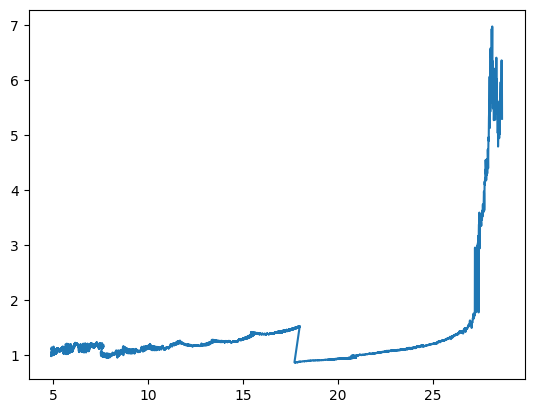

In [46]:
# for idx, xy_width in enumerate(xy_stddev): 
plt.close()
plt.plot(image_properties['wavelength'], xy_stddev[:, 0])
plt.show()

# Translate line position from line list to cube index (location in data cube)

In [47]:
bands = np.unique(image_properties['band_id'])

def determine_cube_index_for_lines(spectrum_df, line_dict, species, bands, use_rv_corr=True):

    result_table = {"species": [], "name": [], "transition": [], "wavelength": [], 'band_id': [], 'cube_index': [],
                   "rotation_angle": [], "pixelscale": []}

    if 'wavelength_rv_corr' in spectrum_df.columns and use_rv_corr:
        wavelength_key = 'wavelength_rv_corr'
    else:
        wavelength_key = 'wavelength'
    print(wavelength_key)
    for band in bands:#np.array(["3A"]):#bands#:

        mask = np.logical_and.reduce([spectrum_df['band_id'] == band, spectrum_df['wavelength'] < 28.5])
        spectrum_seg = spectrum_df[mask]

        minmax = (np.nanmin(spectrum_seg[wavelength_key]), np.nanmax(spectrum_seg[wavelength_key]))  

        for line_species in species:
            species_df = line_dict[line_species].copy().reset_index()
            my_query_index = species_df.query(f'wavelength > {minmax[0]} & wavelength < {minmax[1]}').index
            species_df = species_df.iloc[my_query_index]

            for _, row in species_df.iterrows():
                result_table['species'].append(line_species)
                result_table['name'].append(row['name'])
                result_table['transition'].append(row['transition'])
                result_table['wavelength'].append(row['wavelength'])
                result_table['band_id'].append(band)
                table_position_index = find_nearest(spectrum_seg[wavelength_key], row['wavelength'])
                cube_index = spectrum_seg.iloc[table_position_index].name
    #             print(cube_index)
                result_table['cube_index'].append(cube_index)
                result_table['rotation_angle'].append(spectrum_df.iloc[cube_index].rotation_angle)
                result_table['pixelscale'].append(spectrum_df.iloc[cube_index].pixelscale)

    result_df = pd.DataFrame(result_table)
    return result_df

In [48]:
# Make data frame with all the lines we are searching for and the corresponding index in the spectrum file / combined image cube
result_df = determine_cube_index_for_lines(
    spectrum_df=image_properties, 
    line_dict=line_dict, species=species, bands=bands, use_rv_corr=True)

result_df_no_rv = determine_cube_index_for_lines(
    spectrum_df=image_properties, 
    line_dict=line_dict, species=species, bands=bands, use_rv_corr=False)

wavelength_rv_corr
wavelength


In [49]:
result_df

,species,name,transition,wavelength,band_id,cube_index,rotation_angle,pixelscale
0,H2,"H2 (0,0) S(8)","(0,0) S(8)",5.05303,1A,191,163.365688,0.13
1,H2,"H2 (0,0) S(7)","(0,0) S(7)",5.51116,1A,763,163.365688,0.13
2,H2,"H2 (0,0) S(6)","(0,0) S(6)",6.10856,1B,1610,163.245816,0.13
3,H2,"H2 (0,0) S(5)","(0,0) S(5)",6.90952,1C,2737,163.245655,0.13
4,H2,"H2 (0,0) S(4)","(0,0) S(4)",8.02505,2A,4059,163.105688,0.17
5,H2,"H2 (0,0) S(3)","(0,0) S(3)",9.66491,2B,5398,163.185816,0.17
6,H2,"H2 (0,0) S(2)","(0,0) S(2)",12.27861,3A,7348,162.535688,0.20
7,H2,"H2 (0,0) S(1)","(0,0) S(1)",17.03483,3C,9367,162.535654,0.20
8,H2,"H2 (0,0) S(0)","(0,0) S(0)",28.21883,4C,11556,163.375654,0.35


In [103]:
# Can specify certain transitions, if we don't want to do the analysis for, e.g. all fine-structure lines. We don't want that, it will take forever.
# def retain_rows_by_value(df, column_name, value_list):
#     return df[df[column_name].isin(value_list)]

# list_of_transitions = ['3P1-3P2', 'a6D7/2-a6D9/2', 'a4F5/2-a4F7/2', 'a4F7/2-a4F9/2', '2P1/2-2P3/2', '2D3/2-2D5/2']

# fs_features = retain_rows_by_value(features, column_name='transition', value_list=list_of_transitions)

In [50]:
def continuum_indices(wave_index, reference_range=9, exclude_range=2, exclude_specific_indices=[]):
    index_range = set(range(wave_index - reference_range, wave_index + reference_range+1))
    exclude_indices = set(range(wave_index - exclude_range, wave_index + exclude_range+1))
    if len(exclude_specific_indices) > 0:
        exclude_indices = exclude_indices.union(set(exclude_specific_indices))
    ref_indices = list(index_range - exclude_indices)
    return sorted(list(index_range)), sorted(ref_indices), sorted(list(exclude_indices))

def normalize_cube_with_mask(cube, mask, func=np.nanmedian):
    norm_factors = func(cube[:, mask], axis=1)
    cube_flat = cube.reshape(cube.shape[0], -1)
    cube_flat = cube_flat / norm_factors[:, None]
    cube_norm = cube_flat.reshape(cube.shape[0], cube.shape[1], cube.shape[2])
    return cube_norm

def continuum_subtract_image_simple(data_cube, wave_index, offset=0, reference_range=6, exclude_range=2, 
                                    exclude_specific_indices=[], scale='max', scale_value=1.,
                                    aperture_radius=2., additional_scale_factor=1.):
    # scale: "max", "aperture", "value"
    image = data_cube[wave_index + int(offset)] 
    
    _, reference_indices, _ = continuum_indices(wave_index, reference_range, exclude_range, exclude_specific_indices)
    continuum_image = np.nanmedian(data_cube[reference_indices], axis=0)
    
    if scale == 'max':
        scale_factor = np.nanmax(image) / np.nanmax(continuum_image) * additional_scale_factor
    elif scale == 'value':
        scale_factor = scale_value
    elif scale == 'aperture':
        signal_mask = make_signal_mask(yx_dim=data_cube.shape[1:],
                               pos_yx=(0, 0),
                               mask_radius=aperture_radius,
                               oversampling=1,
                               relative_pos=True,
                               yx_center=None)
        scale_factor = np.mean(image[signal_mask]) / np.mean(continuum_image[signal_mask]) * additional_scale_factor
    else:
        raise ValueError("scale parameter has to be 'max', 'aperture' or 'value'")
    continuum_image *= scale_factor
    cont_sub_image = image - continuum_image 
    cont_sub_image[cont_sub_image == 0.] = np.nan
    
    return cont_sub_image, continuum_image

def subtract_ref_cube_simple(data_cube, ref_cube, reference_range=1, 
                             exclude_specific_indices=[], scale='max', scale_value=1.,
                             aperture_radius=2., additional_scale_factor=1.):
    # scale: "max", "aperture", "value"
        
    subtracted_cube = np.zeros_like(data_cube)
    for idx, image in enumerate(data_cube):
        continuum_image = ref_cube[idx] #np.nanmedian(data_cube[reference_indices], axis=0)
    
        if scale == 'max':
            scale_factor = np.nanmax(image) / np.nanmax(continuum_image) * additional_scale_factor
        elif scale == 'value':
            scale_factor = scale_value
        elif scale == 'aperture':
            signal_mask = make_signal_mask(yx_dim=data_cube.shape[1:],
                                   pos_yx=(0, 0),
                                   mask_radius=aperture_radius,
                                   oversampling=1,
                                   relative_pos=True,
                                   yx_center=None)
            scale_factor = np.mean(image[signal_mask]) / np.mean(continuum_image[signal_mask]) * additional_scale_factor
        else:
            raise ValueError("scale parameter has to be 'max', 'aperture' or 'value'")
        continuum_image *= scale_factor
        cont_sub_image = image - continuum_image 
        cont_sub_image[cont_sub_image == 0.] = np.nan
        subtracted_cube[idx] = cont_sub_image
    
    return subtracted_cube


def fit_background(image, components, bgmask, outlier_percentiles=[0, 100]):
    arr = np.reshape(components, (components.shape[0], -1))
    # Mask: background mask and PCA components are reliable
    bgmask = np.logical_and(bgmask.astype('bool'), components[1] != 0)
    non_outliers = (image > scoreatpercentile(image[bgmask], outlier_percentiles[0])) \
        * (image < scoreatpercentile(image[bgmask], outlier_percentiles[1]))
    bgmask = np.logical_and(bgmask, non_outliers)
    mask = np.reshape(bgmask, -1)

    coef = np.linalg.lstsq((arr[:, mask]).T, np.reshape(image, -1)[mask], rcond=None)[0]

    # This is the fit that we want
    bgfit = np.sum(components*coef[:, np.newaxis, np.newaxis], axis=0)

    return bgfit, coef

def fit_continuum_images(data_cube, wave_index, signal_mask=None, reference_range=6, exclude_range=2,
                         exclude_specific_indices=[],
                         second_iteration=True, sigma=3, outlier_percentiles=[0., 100.]):

    image = data_cube[wave_index].copy()
    reference_indices, _ = continuum_indices(wave_index, reference_range, exclude_range, exclude_specific_indices)
    if signal_mask is None:
        signal_mask = np.ones_like(image).astype('bool')
    ref_cube = data_cube[reference_indices].copy()
    ref_cube_norm = normalize_cube_with_mask(ref_cube, mask=signal_mask, func=np.nanmedian)
    fit, coef = fit_background(image, ref_cube_norm, bgmask=signal_mask, outlier_percentiles=outlier_percentiles)
   
    # Second iteration with mask of deviating pixels
    if second_iteration:
        subbed = image - fit
        # subbed_masked = subbed[signal_mask]
        subbed_flat = subbed.flatten()

        clipped = sigma_clip(subbed_flat, sigma=sigma, sigma_lower=None, sigma_upper=None, maxiters=5, cenfunc=np.nanmedian, 
                             stdfunc=np.nanstd, axis=None, masked=True, return_bounds=False, copy=True, grow=False)
        mask = clipped.mask.reshape(image.shape[0], image.shape[1])

        signal_mask = np.logical_and(~mask, signal_mask)
    
        fit, coef = fit_background(image, ref_cube_norm, bgmask=signal_mask, outlier_percentiles=outlier_percentiles)
        
    psf_sub = image - fit

    return psf_sub, fit, coef, signal_mask

def smooth_cube(data_cube, x_stddev, y_stddev):
    kernel = Gaussian2DKernel(x_stddev=x_stddev, y_stddev=y_stddev)

    data_cube[data_cube == 0.] = np.nan
    bad_data_mask = ~np.isfinite(data_cube)


    data_cube_smooth = np.zeros_like(data_cube)

    for idx, image in enumerate(tqdm(data_cube)):
        data_cube_smooth[idx] = convolve(image, kernel)
    data_cube_smooth[bad_data_mask] = np.nan
    return data_cube_smooth

In [51]:
# Do the extended emission search on a slightly smoothed cube to get rid of sampling effects
if smooth_data:
    data_cube = smooth_cube(data_cube, x_stddev=x_stddev, y_stddev=y_stddev)

100%|████████████| 11637/11637 [00:00<00:00, 11753.41it/s]


If a reference PSF cube exists and both are extracted in Spec3 Step in ifualigned coordinates, we could also try to subtract one cube from the other with a simple scaling, but this is beyond the scope of this tutorial

In [53]:
# smooth_data_cube = smooth_cube(data_cube, x_stddev=5, y_stddev=5)
# smooth_psf_sub = smooth_cube(psf_subtracted_cube, x_stddev=5, y_stddev=5)

# smooth_sub = data_cube - smooth_data_cube

# smooth_psf_subbed_cube = psf_subtracted_cube - smooth_psf_sub

# fits.writeto(os.path.join(output_dir, f'smooth_sub_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'),
#              smooth_sub, overwrite=True)

# fits.writeto(os.path.join(output_dir, f'smooth_psf_sub_orig_binning_{binning}_size_{boxsize_data[0]}_shift_{shift_images}_subpix_{shift_subpixel}.fits'),
#              smooth_sub, overwrite=True)


# # from vip_hci.preproc import frame_rescaling

# # scaling_factors = image_properties['pixelscale'][0]/image_properties['pixelscale']
# # rescaled_cube = []
# # for idx, frame in tqdm(enumerate(psf_subtracted_cube)):
# #     frame_scal = frame_rescaling(frame, scale=scaling_factors[idx], imlib='ndimage', interpolation='biquintic') 
# #     rescaled_cube.append(frame_scal)
# # rescaled_cube = np.array(rescaled_cube)

## Now we define routines that make a reference PSF from the wavelength channels surrounding the expected line channels, which allows to subtract the continuum image from the line

In [61]:
def cont_fit_images_for_lines(
        result_df, data_cube, signal_mask, reference_range=7,
        exclude_range=2, second_iteration=True, sigma=5, outlier_percentiles=[0., 100.],
        smooth_noise=True, smooth_noise_stddev=1.5/2.355):

    line_images = []
    cont_sub_images = []
    cont_sub_images_comparison = []
    psfs = []

    for index in result_df['cube_index'].values:
        _, exclude_indices = continuum_indices(index, reference_range, exclude_range)
        psf_sub, psf, coef, signal_mask = fit_continuum_images(
            data_cube=data_cube, wave_index=index, signal_mask=signal_mask, reference_range=reference_range,
            exclude_range=exclude_range, second_iteration=second_iteration, sigma=sigma,
            outlier_percentiles=outlier_percentiles)

        line_images.append(data_cube[index])
        cont_sub_images.append(psf_sub)
        psfs.append(psf)

        reference_indices_for_line = continuum_indices(index, reference_range=13, exclude_range=5)
        psf_sub_comps = []
        for ref_idx in reference_indices_for_line:
            psf_sub_comparison, _, _, _ = fit_continuum_images(
                data_cube=data_cube, wave_index=ref_idx, signal_mask=signal_mask, reference_range=reference_range,
                exclude_range=exclude_range,
                exclude_specific_indices=exclude_indices,
                second_iteration=second_iteration, sigma=sigma, outlier_percentiles=outlier_percentiles)
            psf_sub_comps.append(psf_sub_comparison)

        cont_sub_images_comparison.append(psf_sub_comps)
    comparison_images = np.array(cont_sub_images_comparison)

    comparison_images[comparison_images == 0.] = np.nan
    noise_maps = mad_std(comparison_images, axis=1, ignore_nan=False, func=np.nanmedian)
    if smooth_noise:
        noise_maps = smooth_cube(noise_maps, x_stddev=smooth_noise_stddev, y_stddev=smooth_noise_stddev)
    
    snr = []
    for idx, image in enumerate(cont_sub_images):
        snr.append(image/noise_maps[idx])
    
    return cont_sub_images, line_images, psfs, comparison_images, snr

In [62]:
def cont_sub_images_for_lines(result_df, data_cube, offset=0, reference_range=7,
                              exclude_range=2, scale='max', scale_value=1.,
                              aperture_radius=2., additional_scale_factor=1.,
                              smooth_noise=True, smooth_noise_stddev=1.5/2.355):

    line_images = []
    cont_sub_images = []
    cont_sub_images_comparison = []
    psfs = []
    comparison_indices = []
    line_indices = []
    
    for index in result_df['cube_index'].values:
        _, _, exclude_indices = continuum_indices(index, reference_range, exclude_range)
        psf_sub, psf = continuum_subtract_image_simple(
            data_cube=data_cube, wave_index=index, offset=offset, reference_range=reference_range, exclude_range=exclude_range,
            scale=scale, scale_value=scale_value, aperture_radius=aperture_radius,
            additional_scale_factor=additional_scale_factor)
        line_images.append(data_cube[index])
        cont_sub_images.append(psf_sub)
        psfs.append(psf)

        reference_indices_for_line, _ = continuum_indices(index, reference_range=13, exclude_range=5)
        psf_sub_comps = []
        for ref_idx in reference_indices_for_line:
            psf_sub_comparison, _ = continuum_subtract_image_simple(
                data_cube=data_cube, wave_index=ref_idx,
                reference_range=reference_range, exclude_range=exclude_range,
                exclude_specific_indices=exclude_indices,
                scale=scale, scale_value=scale_value, aperture_radius=aperture_radius,
                additional_scale_factor=additional_scale_factor)
          
            psf_sub_comps.append(psf_sub_comparison)

        cont_sub_images_comparison.append(psf_sub_comps)
    comparison_images = np.array(cont_sub_images_comparison)

    comparison_images[comparison_images == 0.] = np.nan
    noise_maps = mad_std(comparison_images, axis=1, ignore_nan=True, func=np.nanmedian)
    if smooth_noise:
        noise_maps = smooth_cube(noise_maps, x_stddev=smooth_noise_stddev, y_stddev=smooth_noise_stddev)
    
    snr = []
    for idx, image in enumerate(cont_sub_images):
        snr.append(image/noise_maps[idx])
    
    return cont_sub_images, line_images, psfs, comparison_images, snr

In [63]:
def cont_sub_images_for_lines_new(
        result_df, data_cube, offset=0, explore_index_range=21,
        reference_range=9, exclude_range=3, scale='max', scale_value=1.,
        aperture_radius=2., additional_scale_factor=1.,
        smooth_noise=True, smooth_noise_stddev=1.5/2.355):

    
    result = {}
    result['images'] = []
    result['cont_sub_image'] = []
    result['psfs'] = []
    result['cube_indices'] = []
    result['line_indices'] = []
    
    for index in result_df['cube_index'].values:
        cube_indices, ref_indices, line_indices = continuum_indices(index, explore_index_range, exclude_range)
        result['cube_indices'].append(cube_indices)
        result['line_indices'].append(line_indices)
        print(f"cube indices: {len(cube_indices)}")
        
        result['images'].append(data_cube[cube_indices].copy())
        cont_sub = []
        psfs = []
        
        for cube_index in cube_indices:
#             print(f"cube_index: {cube_index}")
            psf_sub, psf = continuum_subtract_image_simple(
                data_cube=data_cube, wave_index=cube_index, offset=offset, reference_range=reference_range,
                exclude_range=exclude_range, exclude_specific_indices=line_indices,
                scale=scale, scale_value=scale_value, aperture_radius=aperture_radius,
                additional_scale_factor=additional_scale_factor)
            cont_sub.append(psf_sub)
            psfs.append(psf)

        result['cont_sub_image'].append(cont_sub)      
        result['psfs'].append(psfs)

    for key in result:
        result[key] = np.array(result[key])
    
    return result #cont_sub_images, line_images, psfs, comparison_images, snr

In [64]:
# spectral_fit_range = 16
result = cont_sub_images_for_lines_new(
        result_df, data_cube, offset=0, explore_index_range=spectral_fit_range, reference_range=reference_range,
        exclude_range=exclude_range, scale=scale, scale_value=scale_value,
        aperture_radius=aperture_radius,
        additional_scale_factor=additional_scale_factor,
        smooth_noise=smooth_noise, smooth_noise_stddev=smooth_noise_stddev)

cube indices: 43
cube indices: 43
cube indices: 43
cube indices: 43
cube indices: 43
cube indices: 43
cube indices: 43


/var/folders/_c/cxj9fzl943b0jkcttf3vytc59jlp55/T/ipykernel_11755/3928359601.py:23: RuntimeWarning: All-NaN slice encountered
  continuum_image = np.nanmedian(data_cube[reference_indices], axis=0)


cube indices: 43
cube indices: 43


In [65]:
result_df

,species,name,transition,wavelength,band_id,cube_index,rotation_angle,pixelscale
0,H2,"H2 (0,0) S(8)","(0,0) S(8)",5.05303,1A,191,163.365688,0.13
1,H2,"H2 (0,0) S(7)","(0,0) S(7)",5.51116,1A,763,163.365688,0.13
2,H2,"H2 (0,0) S(6)","(0,0) S(6)",6.10856,1B,1610,163.245816,0.13
3,H2,"H2 (0,0) S(5)","(0,0) S(5)",6.90952,1C,2737,163.245655,0.13
4,H2,"H2 (0,0) S(4)","(0,0) S(4)",8.02505,2A,4059,163.105688,0.17
5,H2,"H2 (0,0) S(3)","(0,0) S(3)",9.66491,2B,5398,163.185816,0.17
6,H2,"H2 (0,0) S(2)","(0,0) S(2)",12.27861,3A,7348,162.535688,0.20
7,H2,"H2 (0,0) S(1)","(0,0) S(1)",17.03483,3C,9367,162.535654,0.20
8,H2,"H2 (0,0) S(0)","(0,0) S(0)",28.21883,4C,11556,163.375654,0.35


In [66]:
species_dir = os.path.join(output_dir, f"{'_'.join(species)}")
if not os.path.exists(species_dir):
    os.makedirs(species_dir)
    
plot_dir = os.path.join(species_dir, 'plots_2p4')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### The "result" dictionary entry "cont_sub_image" shows the continuum subtracted images in a wavelength range centered on each line. So it's a multidimensional cube, in which for each line, you can scroll through wavelength to see the 2D line emission image as a function of wavelength. I recommend just opening it in DS9 or similar to explore.

In [67]:
result.keys()
# result['cont_sub_image']
fits.writeto(os.path.join(species_dir, 'continuum_sub_cube.fits'), result['cont_sub_image'], overwrite=True)

In [68]:
result['cont_sub_image'].shape

(9, 43, 45, 45)

Plot the resulting continuum subtracted line cross-sections, the index corresponds to the entry in the line list we fitted
The plot allows us to tell if the width of the PSF appears to be broader inside the line compared to the continuum

/var/folders/_c/cxj9fzl943b0jkcttf3vytc59jlp55/T/ipykernel_11755/3673818951.py:15: RuntimeWarning: All-NaN slice encountered
  continuum_image = np.nanmedian(result['images'][line_id], axis=0)


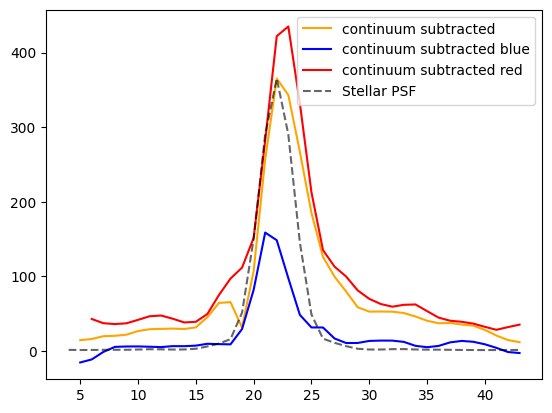

In [73]:
plt.close()
line_id = 7

im_center = result['cont_sub_image'].shape[-1] // 2
wave_idx_center = result['cont_sub_image'].shape[1] // 2

cont_sub_cube = result['cont_sub_image'][line_id]

direction = 'column'

row = im_center

continuum_image = np.nanmedian(result['images'][line_id], axis=0)

if direction == 'row':
    cont_sub_slice_center = cont_sub_cube[wave_idx_center, im_center, :]
    cont_sub_slice_blue = cont_sub_cube[wave_idx_center - 1 , im_center, :]
    cont_sub_slice_red = cont_sub_cube[wave_idx_center + 1 , im_center, :]
    continuum_psf_slice = continuum_image[row, :]
elif direction == 'column':
    cont_sub_slice_center = cont_sub_cube[wave_idx_center, :, im_center]
    cont_sub_slice_blue = cont_sub_cube[wave_idx_center - 1, :, im_center]
    cont_sub_slice_red = cont_sub_cube[wave_idx_center + 1, :, im_center]
    continuum_psf_slice = continuum_image[:, row]
else:
    raise ValueError

plt.close()
plt.plot(cont_sub_slice_center, color='orange', label='continuum subtracted')
plt.plot(cont_sub_slice_blue, color='blue', label='continuum subtracted blue')
plt.plot(cont_sub_slice_red, color='red', label='continuum subtracted red')


plt.plot(
    continuum_psf_slice * np.nanmax(cont_sub_slice_center) / np.nanmax(continuum_psf_slice),
    label='Stellar PSF', color='black', alpha=0.6, linestyle='--')
plt.legend()

We can also try to plot a blue minus red subtracted image of the line, which can be interesting for jets (not for symmetric structures in velocity)

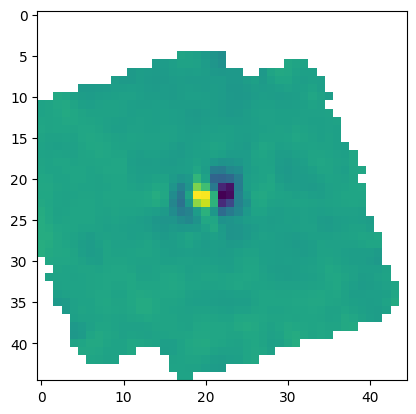

In [80]:
plt.close()
plt.imshow(result['images'][line_id][wave_idx_center-1] - result['images'][line_id][wave_idx_center+2])

In [83]:
image_size = result['images'].shape[-1]
# mask = result['cont_sub_image'][5, 43//2] > 0
mask = np.ones([image_size, image_size]).astype('bool')
# plot_scale(mask)

In [84]:
import pandas as pd
from astropy import units as u
from astropy.constants import c

def compute_resolving_power(wavelength, sub_band=None, overlap='short'):
    """
    Compute the resolving power R = a + b*wavelength for a given sub-band and wavelength,
    and return the FWHM in wavelength (µm) and velocity (km/s). If no sub-band is provided,
    the function determines which sub-band(s) the wavelength may fall into (should be one or
    at most two), and uses the 'overlap' keyword ('short' or 'long') to select the sub-band.

    Parameters:
        wavelength (astropy.units.Quantity): The wavelength at which to compute the resolving power.
            It must have length units (e.g., µm).
        sub_band (str, optional): The sub-band identifier (e.g., "1A", "2C", etc.).
            If None, the function will attempt to determine the correct sub-band.
        overlap (str, optional): In cases where the input wavelength falls into two sub-bands,
            this keyword selects which sub-band to use. Accepted values are 'short' or 'long'.
            Default is 'short'.

    Returns:
        tuple: (R, fwhm_lambda, fwhm_velocity, used_sub_band) where:
            - R (float): The computed resolving power (dimensionless).
            - fwhm_lambda (astropy.units.Quantity): The FWHM in wavelength (in µm).
            - fwhm_velocity (astropy.units.Quantity): The FWHM in velocity (in km/s).
            - used_sub_band (str): The sub-band used in the calculation.

    Raises:
        ValueError: If the wavelength is not an Astropy Quantity, if no candidate sub-band is found,
                    if more than two candidate sub-bands are found, or if the input wavelength is
                    outside the valid range of the (selected) sub-band.
    """
    # Check if wavelength is an Astropy Quantity
    if not isinstance(wavelength, u.Quantity):
        raise ValueError("wavelength must be provided as an astropy Quantity with length units.")

    # Convert the wavelength to micrometers since the coefficients a and b assume µm.
    wavelength_um = wavelength.to(u.um).value

    # Create the DataFrame from the resolving power data

    # Resoling power given by R = a + b * wavelength (micron)
    data = {
        "Sub-band": ["1A", "1B", "1C", "2A", "2B", "2C",
                     "3A", "3B", "3C", "4A", "4B", "4C"],
        "a": [2742, 2742, -543, 332, -331, 430,
              -5120, -1871, -2240, -2066, -1076, -3451],
        "b": [150, 150, 601, 400, 400, 264,
              633, 317, 312, 225, 150, 216],
        "Wavelength (μm)": ["4.90–5.74", "5.66–6.63", "6.53–7.65", 
                             "7.51–8.77", "8.67–10.13", "10.02–11.70", 
                             "11.55–13.47", "13.34–15.57", "15.41–17.98", 
                             "17.70–20.95", "20.69–24.48", "24.19–28.30"],
        "Quality": [4, 2, 2, 3, 3, 4, 
                    1, 1, 4, 4, 4, 4]
    }
    df = pd.DataFrame(data)

    candidates = []  # List to store candidate rows (as Series) where the wavelength fits

    # Iterate over all rows to check if the wavelength falls in the specified range.
    for idx, row in df.iterrows():
        # Parse the wavelength range string
        range_str = row["Wavelength (μm)"].replace("–", "-")
        try:
            lower_str, upper_str = range_str.split("-")
            lower_bound = float(lower_str)
            upper_bound = float(upper_str)
        except Exception as e:
            raise ValueError(f"Error parsing wavelength range '{range_str}': {e}")

        if lower_bound <= wavelength_um <= upper_bound:
            candidates.append(row)

    if sub_band is None:
        if len(candidates) == 0:
            raise ValueError(f"Input wavelength {wavelength_um:.2f} µm does not fall into any sub-band range.")
        elif len(candidates) == 1:
            selected_row = candidates[0]
        elif len(candidates) == 2:
            # Two candidates found. Use the 'overlap' keyword to choose.
            # Sort the candidates by their lower wavelength bound.
            candidates.sort(key=lambda r: float(r["Wavelength (μm)"].replace("–", "-").split("-")[0]))
            if overlap.lower() == 'short':
                selected_row = candidates[0]
            elif overlap.lower() == 'long':
                selected_row = candidates[1]
            else:
                raise ValueError("Invalid value for 'overlap'. Expected 'short' or 'long'.")
        else:
            raise ValueError("More than two candidate sub-bands found, which is unexpected.")
    else:
        # If sub_band is provided, select that row.
        selected_row = df[df["Sub-band"] == sub_band]
        if selected_row.empty:
            raise ValueError(f"Sub-band '{sub_band}' not found in the DataFrame.")
        selected_row = selected_row.iloc[0]  # get the Series
        # Also, check if the provided wavelength is within the range for that sub-band.
        range_str = selected_row["Wavelength (μm)"].replace("–", "-")
        lower_str, upper_str = range_str.split("-")
        lower_bound = float(lower_str)
        upper_bound = float(upper_str)
        if not (lower_bound <= wavelength_um <= upper_bound):
            raise ValueError(
                f"Input wavelength {wavelength_um:.2f} µm is outside the valid range "
                f"{lower_bound}–{upper_bound} µm for sub-band {sub_band}."
            )

    # Now use the coefficients from the selected row.
    used_sub_band = selected_row["Sub-band"]
    a = selected_row["a"]
    b = selected_row["b"]

    # Compute the resolving power: R = a + b * wavelength (with wavelength in µm)
    R = a + b * wavelength_um

    # Compute the FWHM in wavelength: Δλ = λ / R (result in µm)
    fwhm_lambda = (wavelength.to(u.um)) / R

    # Compute the FWHM in velocity: Δv = c / R (convert c to km/s)
    fwhm_velocity = (c / R).to(u.km/u.s)

    return R, fwhm_lambda, fwhm_velocity, used_sub_band

# The main part of this script is fitting a Gaussian at the expected line position to each spaxel, together with an offset and a slope. This produces a map of line intensity

In [85]:
# Make a Gaussian fit of each line for each pixel and turn that into a moment map
fit_results = []

for line_id in tqdm(range(len(result_df))):
    # line_id = 3
    # R = l / dl -> dl = l / R
    # fwhm = 2.3548 * sigma
    # Should actually be added to data frame
    line_rest_wavelength = result_df['wavelength'].iloc[line_id]
    wavelengths_rest = image_properties['wavelength_rv_corr'][result['cube_indices'][line_id]].values
    wavelengths = image_properties['wavelength'][result['cube_indices'][line_id]].values

    # Measure how far the closest spectral bin to the line deviates from the rest velocity line position
    wavelength_deviation = wavelengths_rest - line_rest_wavelength
    channel_line_index = np.argmin(np.abs((wavelength_deviation)))
    channel_deviation_from_rest = wavelength_deviation[channel_line_index]
    
    mid_lambda = wavelengths[channel_line_index]
    print(mid_lambda)
    R, _, _, _ = compute_resolving_power(mid_lambda * u.micron, sub_band=None, overlap='short')
    print(R)
    wavelength_spacing = np.median(np.diff(wavelengths))
    # R = 4603 - 128 * mid_lambda
    spec_fwhm = mid_lambda / R
    fwhm_sampling = spec_fwhm /  np.median(np.diff(wavelengths))
    sigma_sampling = fwhm_sampling / 2.3548

    velocity_per_bin = (wavelength_spacing / mid_lambda * const.c).to(u.km/u.s).value

    image_size = result['images'].shape[-1]
    n_channels = result['images'].shape[1]

    fit_result = {}
    fit_result['fit'] = np.zeros([n_channels, image_size, image_size])
    fit_result['residuals'] = np.zeros([n_channels, image_size, image_size])
    fit_result['amplitude'] = np.zeros([image_size, image_size])
    fit_result['mean'] = np.zeros([image_size, image_size])
    fit_result['mean_kms'] = np.zeros([image_size, image_size])
    fit_result['stddev'] = np.zeros([image_size, image_size])
    fit_result['wavelength'] = wavelengths
    fit_result['R'] = R
    fit_result['fwhm_sampling'] = fwhm_sampling
    fit_result['spec_fwhm'] = spec_fwhm
    fit_result['pixelscale'] = image_properties['pixelscale'][result['cube_indices'][line_id]].values[channel_line_index]
    fit_result['velocity_per_bin'] = velocity_per_bin
    
    for i in range(image_size):
        for j in range(image_size):
            pixel = result['images'][line_id, :, i, j]
            # Put channel closest to rest frame wavelength of line at 0
            X_obs = np.arange(len(pixel)) - channel_line_index
            if (np.all(np.isfinite(pixel)) and np.all(pixel != 0.)) and mask[i, j]:
                gauss_model = models.Gaussian1D(
                    amplitude=np.nanmax(pixel),
                    mean=0, #len(pixel)//2,
                    stddev=sigma_sampling,
                    bounds={"stddev": (sigma_sampling-0.2, sigma_sampling+0.2),
                           "amplitude": (0, 1e10),
                           "mean": (-2, 2)})
                gauss_model.stddev.fixed = True
                lin_model = models.Linear1D(slope=0., intercept=np.quantile(pixel, 0.05))
                model_init = gauss_model + lin_model #models.Const1D(np.quantile(pixel, 0.05)) # type: ignore
                fit_g = fitting.LevMarLSQFitter()
                # print(f"X_obs: {X_obs}")
                # print(f"pixel: {pixel}")
                # print(f"model_init: {model_init}")
                try:
                    g = fit_g(model_init, X_obs, pixel, filter_non_finite=True)
                    fit_result['fit'][:, i, j] = g(X_obs)
                    fit_result['residuals'][:, i, j] = pixel - g(X_obs)
                    fit_result['amplitude'][i, j] = g.amplitude_0.value
                    fit_result['mean'][i, j] = g.mean_0.value + channel_deviation_from_rest
                    fit_result['mean_kms'][i, j] = (g.mean_0.value + channel_deviation_from_rest) * velocity_per_bin
                    fit_result['stddev'][i, j] = g.stddev_0.value       
                except:
                    fit_result['fit'][:, i, j] = np.zeros(len(X_obs)) * np.nan
                    fit_result['residuals'][:, i, j] = np.zeros(len(X_obs)) * np.nan
                    fit_result['amplitude'][i, j] = np.nan
                    fit_result['mean'][i, j] = np.nan 
                    fit_result['mean_kms'][i, j] = np.nan
                    fit_result['stddev'][i, j] = np.nan                    
            else:
                fit_result['fit'][:, i, j] = np.zeros(len(X_obs)) * np.nan
                fit_result['residuals'][:, i, j] = np.zeros(len(X_obs)) * np.nan
                fit_result['amplitude'][i, j] = np.nan
                fit_result['mean'][i, j] = np.nan 
                fit_result['mean_kms'][i, j] = np.nan
                fit_result['stddev'][i, j] = np.nan
    fit_results.append(fit_result)

  0%|                               | 0/9 [00:00<?, ?it/s]

5.053200091497274
3499.980013724591


 11%|██▌                    | 1/9 [00:02<00:17,  2.14s/it]

5.510800079937326
3568.620011990599


 22%|█████                  | 2/9 [00:04<00:14,  2.05s/it]

...

 78%|█████████████████▉     | 7/9 [00:13<00:03,  1.76s/it]

17.03374981111847
3074.529941068962


 89%|████████████████████▍  | 8/9 [00:14<00:01,  1.66s/it]

28.218999651726335
2644.3039247728884


100%|███████████████████████| 9/9 [00:15<00:00,  1.76s/it]


In [87]:
print(sigma_sampling)
print(f"Wavelength: {mid_lambda}")

0.7553095281135817
Wavelength: 28.218999651726335


In [88]:
fit_results[3]['wavelength']
# fit_results[1]['fit'].shape
im_center = fit_results[0]['fit'].shape[-1] // 2

fit_results[3]['fit'][:, im_center, im_center]

array([28077.44645531, 28080.77743005, 28084.1084048 , 28087.43937954,
       28090.77035428, 28094.10132902, 28097.43230376, 28100.7632785 ,
       28104.09425325, 28107.42522799, 28110.75620273, 28114.08717747,
       28117.41815221, 28120.74912695, 28124.08010171, 28127.41108896,
       28130.74552209, 28134.43829505, 28151.99724901, 28362.0749436 ,
       29418.5563894 , 30933.40383527, 30462.77493753, 28882.47576927,
       28244.51272921, 28164.67679674, 28164.11999214, 28167.38321961,
       28170.71374919, 28174.04472282, 28177.37569756, 28180.7066723 ,
       28184.03764705, 28187.36862179, 28190.69959653, 28194.03057127,
       28197.36154601, 28200.69252075, 28204.0234955 , 28207.35447024,
       28210.68544498, 28214.01641972, 28217.34739446])

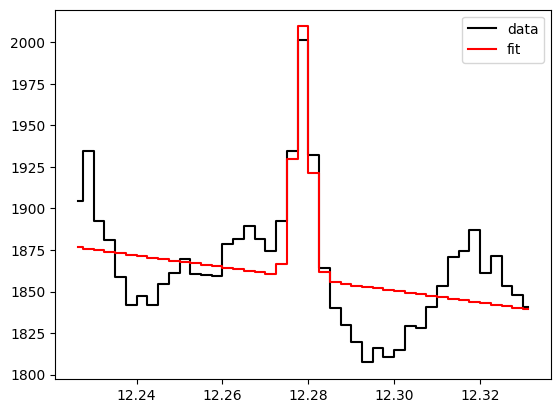

In [89]:
# Visualize the line fit for a certain pixel
%matplotlib inline
plt.close()
line_id = 6
x = im_center + 3
y = im_center - 2

plt.step(fit_results[line_id]['wavelength'], result['images'][line_id][:, y, x], color='black', label='data', where='mid')
plt.step(fit_results[line_id]['wavelength'], fit_results[line_id]['fit'][:, y, x], color='red', label='fit', where='mid')

plt.legend()

In [90]:
# Not yet sure if this is reliable
line_id = 3
fit_results[line_id]['velocity_per_bin']

np.float64(34.71025144605156)

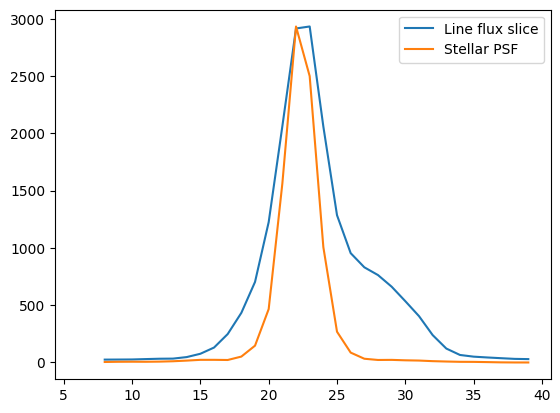

In [91]:
# Visualize a slice through the center of the image to check if line emission is extended compared to the continuum

# plot_scale(fit_amplitude)
# plot_frames(fit_amplitude, vmin=0., vmax=2000)
row = im_center
line_id = 3

row = fit_results[line_id]['amplitude'].shape[-1] // 2
fit_amp = fit_results[line_id]['amplitude'][:, row]
continuum_image = np.median(result['images'][line_id], axis=0)

plt.plot(fit_amp, label='Line flux slice')
plt.plot(
    continuum_image[:, row] * np.nanmax(fit_amp) / np.nanmax(continuum_image[:, row]),
    label='Stellar PSF')
plt.legend()


## Make a master plot of the line amplitudes and offsets (potentially widths).
### For now it is better to trust only the amplitudes and not the offsets and widths. These proceedures should be refined in the future. Line widths are tricky due to instrumental and detector effects and offsets depend on the wavelength calibration and reference values to be precise. This also assumes that only one velocity component is visible, but there may be multiple (e.g. jets, front and back of the disk)

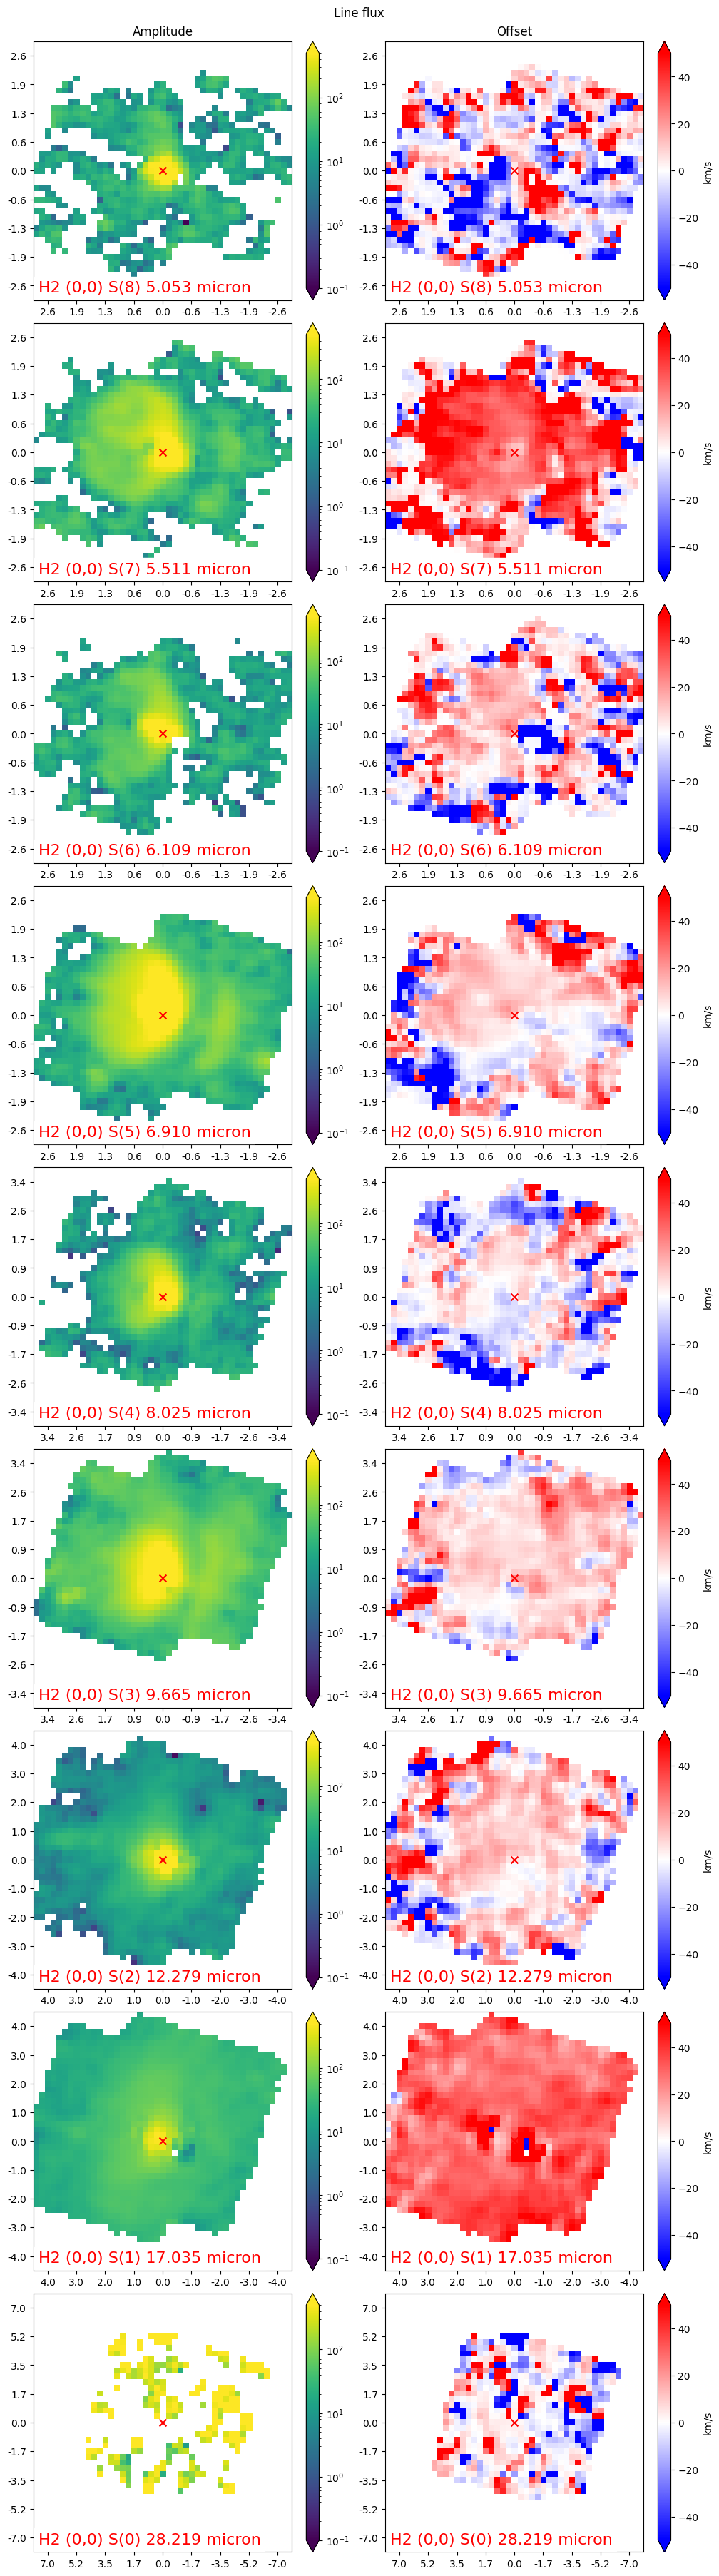

In [92]:
nimages = len(result_df)

shrink = 1
col_names = ['Amplitude', 'Offset', 'Width']
ncols = 2

vmax = 500

plt.close()
fig, axs = plt.subplots(figsize=(5*ncols, 4*nimages), ncols=2, nrows=nimages, layout="constrained")

ang_ticksep = 5
ndec = 1
colormap = 'bwr' # 'PiYG'

# test = axs[0, 0]
for line_idx, row in enumerate(range(nimages)):
    pixel_scale = fit_results[row]['pixelscale']
    image_size = fit_results[row]['amplitude'].shape[-1]
    cy = image_size // 2
    
    half_num_ticks = int(np.round(cy // ang_ticksep))

    
    # Calculate the pixel locations at which to put ticks
    ticks = []
    for t in range(half_num_ticks, -half_num_ticks-1, -1):
        # Avoid ticks not showing on the last pixel
        if not cy - t * ang_ticksep == image_size:
            ticks.append(cy - t * ang_ticksep)
        else:
            ticks.append((cy - t * ang_ticksep)-1)

    # Corresponding distance in arcseconds, measured from the center
    labels_y = []
    labels_x = []
    for t in range(half_num_ticks, -half_num_ticks-1, -1):
        labels_y.append(round(Decimal(-t * (ang_ticksep * pixel_scale)), ndec))
        labels_x.append(round(Decimal(t * (ang_ticksep * pixel_scale)), ndec))

    
    amp_plot = axs[row, 0].imshow(
        fit_results[row]['amplitude'],
        cmap='viridis', norm=LogNorm(vmin=0.1, vmax=vmax),
        interpolation='none', origin='lower',
#         extent=[-half_size, half_size, -half_size, half_size],
        aspect='equal',
    )
    axs[row, 0].set_xticks(ticks)
    axs[row, 0].set_yticks(ticks)    
    axs[row, 0].set_xticklabels(labels_x)
    axs[row, 0].set_yticklabels(labels_y)
    
    _ = fig.colorbar(amp_plot, ax=axs[row, 0], extend='both', location='right', anchor=(0, 0.5), shrink=shrink)
#     cbar1.minorticks_on()
    
    shift_plot = axs[row, 1].imshow(
        fit_results[row]['mean_kms'], cmap=colormap, vmin=-50, vmax=50,
        interpolation='none', origin='lower',
#         extent=[-half_size, half_size, -half_size, half_size],
        aspect='equal',
    )
    axs[row, 1].set_xticks(ticks)
    axs[row, 1].set_yticks(ticks)    
    axs[row, 1].set_xticklabels(labels_x)
    axs[row, 1].set_yticklabels(labels_y)
    _ = fig.colorbar(shift_plot, ax=axs[row, 1], extend='both', location='right', anchor=(0, 0.5), shrink=shrink,
                    label='km/s')

yx_coords = np.array([cy, cy])
color = 'black'
point_size = 10
plot_star_not_circle = True

for row in range(nimages):
    df_row = result_df.iloc[row]
    name = label = f"{df_row['name']} {df_row['wavelength']:0.3f} micron"
    for col in range(ncols):
        axs[row, col].annotate(f'{name}', (0.4, 0.4),
                               transform=axs[row, col].transAxes,
                               ha='left', va='bottom', fontsize=16,
                               color='red', backgroundcolor='white')
        
        axs[row, col].scatter(cy, cy, s=50, c='red', marker='x')
        
for ax, col in zip(axs[0], col_names):
    ax.set_title(col)

fig.suptitle('Line flux')

fig.savefig(os.path.join(plot_dir, 
    f"{target_name}_{'_'.join(species)}_fit_extended_emission_ref_{reference_range}_excl_{exclude_range}_smooth_{smooth_data}_{x_stddev:.2f}_2.png"), dpi='figure')
# plt.tight_layout()

In [94]:
# Example using gofish package for making radial profiles of disks
# from gofish import imagecube

# cube_sphere = imagecube(
#     'PDS70_S1_amplitude_cube.fits', #path.join(directory_sphere, filename_sphere), 
#     bunit='Jy',
#     pixel_scale=0.2)#, FOV=10.0)
# # psf = np.median(result['psfs'][7][18:23], axis=0)
# # plot_scale(psf)

# x, y, dy = cube_sphere.radial_profile(
#     x0=0.0, y0=0.0, inc=0, PA=0,
#     r_min=0., r_max=2.5,
#     mstar=0.88, dist=59.5, unit='Jy/beam')

# # Plot
# fig, ax = plt.subplots()
# ax.errorbar(x, y, dy, fmt=' ', capsize=1.25, capthick=1.25, color='k', lw=1.0)
# ax.step(x, y, where='mid', color='k', lw=1.0)
# ax.set_xlim(x.min(), x.max())
# ax.set_xlabel('Radius (arcsec)')
# # ax.set_ylabel('Peak Intensity (Jy/beam)')
# ax.set_ylabel('Peak Intensity (arb. units)')

# """rvals=None, rbins=None, 
# dr=None, unit='Jy/beam m/s', x0=0.0, y0=0.0,
# inc=0.0, PA=0.0, z0=0.0, psi=1.0, r_cavity=0.0,
# q_taper=1.0, z_func=None, mstar=0.0, dist=100.0,
# resample=1, beam_spacing=False, r_min=None,
# r_max=None, PA_min=None, PA_max=None,
# exclude_PA=False, abs_PA=False, mask_frame='disk',
# mask=None, velo_range=None, assume_correlated=True,
# shadowed=False"""

In [95]:
# Attempt at deconvolusion, not working properly yet

# def extract_box(cube, image_center=None, boxsize=np.array([35, 35])):
#     if image_center is None:
#         image_center = np.array(cube.shape[1:]) // 2

#     cube_cutout = cube[:, image_center[0]-boxsize[0]//2:image_center[0]+boxsize[0]//2+1,
#                        image_center[1]-boxsize[1]//2:image_center[1]+boxsize[1]//2+1].copy()
#     return cube_cutout

# # image_cube = extract_box(cont_sub_images, boxsize=np.array([47, 47]))
# # ref_psf = extract_box(psf_cube_full, boxsize=np.array([31, 31]))

# image = extract_box(np.expand_dims(fit_amplitude,0), boxsize=np.array([21, 21]))[0] #cont_sub_images[7]
# psf_for_deconv = extract_box(np.expand_dims(psf, 0), boxsize=np.array([21, 21]))[0]#result['psf']#psf_cube_full[7]

# epsilon = 1e-8

# image[~np.isfinite(image)] = epsilon
# image[image<=0.] = epsilon
# # image[image<0]
# psf_for_deconv[~np.isfinite(psf_for_deconv)] = epsilon
# psf_for_deconv[psf_for_deconv<=0.] = epsilon

# psf_for_deconv = psf_for_deconv / np.sum(psf_for_deconv)
# deconvolved_RL_H2_new = restoration.richardson_lucy(image, psf_for_deconv, iterations=5,
#                                                     filter_epsilon=1e-5)